# Flowception — tutorial notebook

This notebook is a **ready-to-run, minimal tutorial** for the FlowCeption training + sampling loop, using a tiny
synthetic dataset (3×3 RGB “videos”) so you can **see every moving part** without GPU-scale complexity.

What you’ll learn:

1. **Toy data generation** — variable-length videos built from a simple, deterministic rule (rotating boundary colors)
2. **Core utilities** — left-alignment, insertion-count bookkeeping, Poisson/rate loss, and SNR time-warping helpers
3. **$\tau$ / $\tau_{\max}$ sampling** — per-frame insertion clocks + a shared global clock, yielding per-frame $\tau_i$
4. **Training** — velocity loss + insertion-rate (Poisson) loss with correct masking
5. **Sampling** — alternating flow updates + stochastic insertions (Bernoulli thinning) to grow the sequence
6. **Visualization** — qualitative rollouts + length statistics

> **Tip:** Because everything is tiny, this notebook is great for debugging masks, time conventions, and insertion logic
before scaling up to real video models.


## 0. Imports & Setup

In [1]:
# Copyright (c) Meta Platforms, Inc. and affiliates.
# All rights reserved.

# This source code is licensed under the license found in the
# LICENSE file in the root directory of this source tree.

%load_ext autoreload
%autoreload 2

import os, io, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import tqdm
from einops import rearrange

import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, clear_output
from IPython.display import Image as IPImage

plt.rcParams["figure.figsize"] = (3, 2)
torch.set_printoptions(threshold=10_000)

device = "cuda:0" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda:0


In [2]:
import cv2, os
from pathlib import Path
import numpy as np
from PIL import Image
import io
from IPython.display import Image as ip_im


def write_frames_to_video(
    frames,
    outpath,
    fps=24,
):
    assert outpath.endswith(".mp4")
    assert frames.ndim == 4

    outdir = Path(outpath).parent
    os.makedirs(outdir, exist_ok=True)

    # Define the video properties
    width = frames.shape[-2]
    height = frames.shape[-3]

    # Create a VideoWriter object
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    out = cv2.VideoWriter(outpath, fourcc, fps, (width, height))

    # Generate some frames
    for i in range(len(frames)):
        frame = frames[i, :, :, ::-1]
        out.write(frame)

    # Release resources
    out.release()


import imageio.v3 as iio


def write_frames_ffmpeg(frames, outpath, fps=24):
    frames = np.asarray(frames)
    if frames.dtype != np.uint8:
        frames = ((np.clip(frames, -1, 1) + 1.0) * 0.5 * 255.0).round().astype(np.uint8)
    iio.imwrite(
        outpath,
        frames,
        plugin="FFMPEG",
        fps=fps,
        codec="libx264",
        pixelformat="yuv420p",  # widely compatible
        macro_block_size=None,  # allows odd sizes
    )


def frames_to_gif(frames_t, fps=24, save_path=None):
    # List of frames as numpy arrays
    frames = [
        (255 * (frames_t[:, i].clip(0, 1)).transpose(1, 2, 0)).astype(np.uint8)
        for i in range(frames_t.shape[1])
    ]

    # Convert the frames to Pillow images
    images = [Image.fromarray(frame) for frame in frames]

    # Create a BytesIO buffer
    buf = io.BytesIO()

    # Save the frames as a GIF to the buffer
    images[0].save(
        buf,
        format="GIF",
        save_all=True,
        append_images=images[1:],
        duration=int(1000 / fps),  # Duration of each frame in milliseconds
        loop=0,
    )  # Loop the GIF indefinitely

    # Get the GIF data from the buffer
    gif_data = buf.getvalue()
    if save_path is not None:
        with open(save_path, "wb") as f:
            f.write(gif_data)
    return ip_im(data=gif_data)

## 1. Toy Data — Rotating Coloring Videos

In [3]:
def generate_projected_coloring_video_batch(
    batch_size=16,
    T_max=30,
    device="cuda",
    padding_idx=3,
    min_length=5,
    max_length=30,
    valid_stride_choices=(1, 2, 3),
):
    """Generate variable-length 3x3 coloring videos with rotating boundary colors."""
    boundary_path = torch.tensor([0, 1, 2, 5, 8, 7, 6, 3], device=device)
    center_idx = 4
    flat_to_ij = torch.tensor(
        [(0, 0), (0, 1), (0, 2), (1, 0), (1, 1), (1, 2), (2, 0), (2, 1), (2, 2)],
        device=device,
    )

    valid_lengths = torch.arange(min_length, max_length + 1, step=5, device=device)
    video_lengths = valid_lengths[torch.randint(0, len(valid_lengths), (batch_size,), device=device)]
    stride_choices = torch.tensor(valid_stride_choices, device=device)
    strides = stride_choices[torch.randint(0, len(stride_choices), (batch_size,), device=device)]

    c1 = torch.rand(batch_size, 3, device=device)[..., None]
    c2 = torch.rand(batch_size, 3, device=device)[..., None]
    dx = torch.linspace(0, 1, steps=9, device=device)[None, None, :]
    color_seq = (c1 * dx + c2 * (1 - dx)).permute(0, 2, 1)  # [B, 9, 3]
    boundary_colors = color_seq[:, :8, :]  # [B, 8, 3]
    center_colors = color_seq[:, 8, :]  # [B, 3]

    videos = torch.full(
        (batch_size, T_max, 3, 3, 3), fill_value=padding_idx, device=device, dtype=torch.float32
    )

    t = torch.arange(T_max, device=device).unsqueeze(0).expand(batch_size, -1)
    mask = t < video_lengths.unsqueeze(1)
    shift = (t * strides.unsqueeze(1)) % 8

    base_color_idx = torch.arange(8, device=device)
    all_color_rolls = torch.stack([torch.roll(base_color_idx, -s) for s in range(8)], dim=0)
    rolled_color_idx = all_color_rolls[shift]  # [B, T, 8]

    for pi in range(8):
        grid_idx = boundary_path[pi]
        i, j = flat_to_ij[grid_idx]
        color_idx = rolled_color_idx[:, :, pi]
        gathered_color = torch.gather(boundary_colors, 1, color_idx.unsqueeze(-1).expand(-1, -1, 3))
        target = videos[:, :, :, i, j]
        target.masked_scatter_(mask.unsqueeze(-1), gathered_color[mask])

    i, j = flat_to_ij[center_idx]
    center_expanded = center_colors.unsqueeze(1).expand(-1, T_max, -1)
    center_target = videos[:, :, :, i, j]
    center_target.masked_scatter_(mask.unsqueeze(-1), center_expanded[mask])

    return videos, mask, video_lengths, strides

Video shapes: torch.Size([4, 30, 3, 3, 3]), Lengths: [15, 30, 15, 20]
  Video 0: 15 valid frames


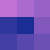

  Video 1: 30 valid frames


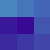

  Video 2: 15 valid frames


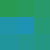

  Video 3: 20 valid frames


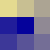

In [4]:
# Quick visualization
videos, mask, lengths, strides = generate_projected_coloring_video_batch(
    batch_size=4, T_max=30, device=device, padding_idx=3, min_length=10, max_length=30
)
print(f"Video shapes: {videos.shape}, Lengths: {lengths.tolist()}")

for i in range(min(4, videos.shape[0])):
    vid = videos[i]  # [T, C, H, W]
    m = mask[i]  # [T] bool
    vid_up = F.interpolate(vid.float(), size=(50, 50), mode="nearest")
    vid_valid = vid_up[m]
    frames_np = vid_valid.permute(1, 0, 2, 3).detach().cpu().numpy()
    print(f"  Video {i}: {vid_valid.shape[0]} valid frames")
    display(frames_to_gif(frames_np, fps=10))

## 2. Constants & Helpers

In [ ]:
# --- Global constants ---
num_frames = 30
H, W, C = 3, 3, 3
padding_index = 3  # value used for padded (absent) frames
num_start_frames = 3  # how many seed frames at t=0
sigma_scale = 1.0  # SNR shift (set >1 for heavier warping)

print(f"Config: {num_frames} frames, {H}x{W}x{C} pixels, padding={padding_index}")

Config: 30 frames, 3x3x3 pixels, padding=3


In [7]:
def frames_to_gif(frames_t, save_path=None, fps=24):
    """Convert [T, C, H, W] float frames to a GIF (returns IPython Image)."""
    frames = [(255 * frame).clip(0, 255).astype(np.uint8) for frame in frames_t]
    if frames[-1].ndim == 2:
        images = [Image.fromarray(frame) for frame in frames]
    else:
        images = [Image.fromarray(frame.transpose(1, 2, 0)) for frame in frames]

    buf = io.BytesIO()
    images[0].save(
        buf,
        format="GIF",
        save_all=True,
        append_images=images[1:],
        duration=int(1000 / fps),
        loop=0,
    )
    gif_data = buf.getvalue()
    if save_path is not None:
        os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
        with open(save_path, "wb") as f:
            f.write(gif_data)
    return IPImage(data=gif_data)

In [9]:
# ---------- SNR warping ----------
def scale_snr(u, sigma_scale=1.0):
    """Warp uniform time u ∈ [0,1] to denoising time t, applying SNR shift."""
    return u / (1 + (sigma_scale - 1) * (1 - u))


# ---------- Left-alignment ----------
def left_align_by_mask(x, mask):
    """
    Left-align True positions in `mask` [B,L] to the front of each sequence in `x` [B,L,...].
    Returns (x_aligned, sort_order [B,L]).
    """
    B, L = mask.shape
    m = mask.int()
    sort_order = torch.argsort(-m, dim=1, stable=True)  # [B,L]
    index_shape = sort_order.shape + (1,) * (x.ndim - 2)
    sort_exp = sort_order.view(*index_shape).expand_as(x)
    x_aligned = torch.gather(x, dim=1, index=sort_exp)
    return x_aligned, sort_order


# ---------- Insert-count computation ----------
def compute_insert_counts(insert_site_mask, flow_site_mask):
    """
    For each flow frame i, count how many insert sites lie between i and the next flow frame.
    Returns [B, L] int tensor (-1 where flow_site_mask is False).
    """
    B, L = insert_site_mask.shape
    device = insert_site_mask.device

    idx = torch.arange(L, device=device)
    flow_exp = flow_site_mask.view(B, 1, L)
    i_idx = idx.view(1, L, 1).expand(B, L, L)
    j_idx = idx.view(1, 1, L).expand(B, L, L)

    valid_next = (j_idx > i_idx) & flow_exp
    j_masked = torch.where(valid_next, j_idx, L)
    next_real = j_masked.min(dim=2).values

    window = (j_idx > i_idx) & (j_idx < next_real.unsqueeze(2))
    ins_exp = insert_site_mask.view(B, 1, L).expand(B, L, L)
    counts = (window & ins_exp).sum(dim=2)
    counts = torch.where(flow_site_mask, counts, torch.full_like(counts, -1))
    return counts


# ---------- Start-frame sampling ----------
def sample_start_frames(M1, k=10, skip_first=1):
    """
    Randomly select k seed-frame positions from valid frames (M1==True),
    skipping the first `skip_first` frames (which are always kept).
    Returns a [B, L] bool mask.
    """
    B, L = M1.shape
    device = M1.device
    start_p = k / L
    start_frames = (torch.rand(B, L, device=device) < start_p) & M1
    if skip_first > 0:
        start_frames[:, :skip_first] = False
    # Always include frame 0
    start_frames[:, 0] = True
    return start_frames


def poisson_loss(rate, k, M, tau_0):
    loss = rate - k * torch.log(rate + 1e-8)
    loss = torch.where(M, loss, 0.0)
    return loss.sum() / M.sum()

In [10]:
# ---------- Data wrapper ----------
def gen_z1(batch_size, padding_idx=3, device="cpu"):
    """
    Generate a batch of normalized coloring videos.
    Returns:
        z_batch: [B, T, C, H, W] normalized to roughly N(0,1)-scale
        M1:      [B, T] bool — True for valid (non-padding) frames
        vid_lengths: [B] int
    """
    batch, no_insert_mask, video_lengths, strides = generate_projected_coloring_video_batch(
        batch_size=batch_size,
        T_max=num_frames,
        device=device,
        padding_idx=padding_idx,
        min_length=15,
        max_length=30,
        valid_stride_choices=(1, 2, 3),
    )
    z_batch = (batch - 0.5) / 0.25  # normalize
    return z_batch, no_insert_mask, video_lengths

## 3. $\tau$ / $\tau_{\max}$ Sampling

A key design choice in FlowCeption is to represent *sequence growth* with a **per-frame insertion clock** and a
**global clock**:

1. Sample per-frame insertion clocks
   $$t^{\text{ins}}_i \sim \mathcal{U}(0,1).$$

2. Compute the maximum clock over **candidate frames** (non-context, non-padding), then shift by 1:
   $$\tau_{\max} = \max_i\; t^{\text{ins}}_i + 1.$$

3. Sample a *global* clock (here: uniform, but other distributions are possible):
   $$\tau_{\text{global}} \sim \mathcal{U}(0, \tau_{\max}).$$

4. Convert to per-frame time:
   $$\tau_i = \tau_{\text{global}} - t^{\text{ins}}_i.$$

5. Interpret $\tau_i$:
   - **Active flow sites:** $\tau_i \in [0,1)$  
   - **Not-yet-inserted:** $\tau_i < 0$  
   - **Already-resolved / context:** typically masked out by the context/padding logic

This construction makes it easy to (a) train a denoiser/velocity field on a consistent time window $[0,1)$, while
(b) letting the model learn *when* new frames should be inserted via a separate **rate** (or “insertion intensity”)
head.


In [11]:
def sample_tau_tau_max(
    start_frames,  # [B, L] bool
    M1,  # [B, L] (1 == real/kept frame)
    ctx_mask,  # [B, L] (True == context to exclude from inserts)
    vid_lengths,  # [B]    valid video length per sample
    device=None,
    global_dist="uniform",  # "uniform" | "lognorm"
    max_tries=8,
):
    """
    Sample per-frame tau values using the tau_max scheme.
    Returns:
        tau:        [B, L]  per-frame denoising time
        tau_global: [B]     the sampled global tau
    """
    if device is None:
        device = start_frames.device
    B, L = start_frames.shape
    eps = 1e-3

    # candidate mask: where we want signal (real, non-context, within valid length)
    frame_idx = torch.arange(L, device=device)[None, :]
    valid_len = frame_idx < vid_lengths[:, None]
    cand = M1.bool() & (~ctx_mask.bool()) & valid_len
    has_any_cand = cand.any(dim=1)

    t_ins_all = torch.zeros(B, L, device=device)
    tau_all = torch.zeros(B, L, device=device)
    tau_global_all = torch.zeros(B, 1, device=device)

    need = has_any_cand.clone()
    tries = 0

    while need.any() and tries < max_tries:
        idx = torch.where(need)[0]
        Bbad = idx.numel()
        if Bbad == 0:
            break

        # 1) sample t_ins in [0,1)
        t_ins_bad = torch.rand(Bbad, L, device=device)
        sf_bad = start_frames[idx]
        t_ins_bad = torch.where(sf_bad, torch.zeros_like(t_ins_bad), t_ins_bad)

        # 2) tau_max = max candidate t_ins + 1
        cand_bad = cand[idx]
        minus_inf = torch.full_like(t_ins_bad, -1e9)
        t_ins_cand = torch.where(cand_bad, t_ins_bad, minus_inf)
        t_max = t_ins_cand.max(dim=1).values
        has_any_here = t_max > -1e8
        t_max = torch.where(has_any_here, t_max, torch.ones_like(t_max))
        tau_max = t_max + 1.0 - eps

        # 3) tau_global ~ (0, tau_max)
        if global_dist == "lognorm":
            e0 = torch.randn(Bbad, 1, device=device)
            u = torch.sigmoid(e0).clamp(None, 1.0 - eps)
        else:  # uniform
            u = torch.rand(Bbad, 1, device=device).clamp(None, 1.0 - eps)

        tau_global_bad = u * tau_max.unsqueeze(1)

        # 4) tau_i = tau_global - t_ins_i
        tau_bad = tau_global_bad - t_ins_bad

        t_ins_all[idx] = t_ins_bad
        tau_all[idx] = tau_bad
        tau_global_all[idx] = tau_global_bad

        # check: at least one candidate has tau in [0,1)
        signal_mask_bad = cand_bad & (tau_bad >= 0.0) & (tau_bad < 1.0)
        ok_bad = signal_mask_bad.any(dim=1)
        need[idx[ok_bad]] = False
        tries += 1

    # Minimal repair for still-bad rows
    still_bad = has_any_cand & need
    if still_bad.any():
        idx = torch.where(still_bad)[0]
        Brepair = idx.numel()
        cand_bad = cand[idx]
        t_ins_bad = t_ins_all[idx]
        j = torch.multinomial(cand_bad.float() + 1e-8, num_samples=1).squeeze(1)
        tau_star = torch.rand(Brepair, device=device)
        tau_all[idx, j] = tau_star
        tau_global_all[idx, 0] = tau_star + t_ins_bad[torch.arange(Brepair, device=device), j]

    return tau_all, tau_global_all.squeeze(1)

## 4. Model Definition

A small Transformer that takes flattened 3×3×3 frame tokens, per-frame time embeddings,
and outputs velocity predictions + insertion-rate logits per frame.

In [12]:
# import os
# %cd ./flow_matching/examples/edit_flows
# os.getcwd()

In [38]:
from omegaconf.dictconfig import DictConfig
from toy_transformer import Transformer

model_config = DictConfig(
    {
        "hidden_size": 256,
        "cond_dim": 64,
        "length": 1024,
        "n_blocks": 8,
        "n_heads": 8,
        "dropout": 0.0,
        "max_period": 0.006,
        "rope_base": 10000,
        "input_dim": H * W * C,
        "out_channels": H * W * C,
        "max_insertions": num_frames,
        "miniflow_feats": 512,
    }
)

vocab_size = 1 + 3  # 1 character + DEL + EOS + padding

model = Transformer(config=model_config).to(device=device)
model.train(True)
model = torch.compile(model)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 7,436,188


In [39]:
# ---------- Model wrapper ----------
def compute_model(x_t, time, mask, model):
    """
    Forward pass: flatten spatial dims, run transformer, reshape.
    Returns (velocity [B,L,H,W,C], lambda_ins [B,L]).
    """
    b, d, h, w, c = x_t.shape
    x_t_flat = rearrange(x_t, "b d h w c -> b d (h w c)")

    model_output = model(
        x_t=x_t_flat,
        time=time,
        mask=mask,
    )

    global_velocity, lambda_ins = model_output
    lambda_ins = F.softplus(lambda_ins)
    global_velocity = rearrange(global_velocity, "b d (h w c) -> b d h w c", h=h, w=w, c=c)

    return global_velocity, lambda_ins.squeeze(-1)

## 5. Training Loop

In this tutorial training loop we optimize **two coupled objectives**:

- **Flow / velocity loss** on *active* sites ($\tau_i \in [0,1)$)
- **Insertion-rate loss** (Poisson-style) that teaches the model *how many* new frames to insert as the clock advances

Practical differences vs. earlier versions:

- Uses `sample_tau_tau_max` (global $\tau$ + per-frame insertion clocks) rather than manual `t_global`
- Applies `scale_snr` to map a uniform clock to an SNR-warped denoising time
- Uses `valid_flow_mask` to enforce both *structural* validity (non-padding / non-context) and *temporal* validity
  ($\tau$ bounds)
- Passes $\tau$ into the rate loss so weighting matches the time convention


In [51]:
# ---------- Training hyperparameters ----------
batch_size = 512
lr = 1e-3
num_iter = 20001

optimizer = torch.optim.Adam(model.parameters(), lr=lr)

loss_dict = {
    "loss": [],
    "vel_loss": [],
    "rate_loss": [],
    "insert_std": [],
    "insert_std_real": [],
}

time_stats = {"data": [], "forward": [], "backward": [], "loss": [], "transform": []}

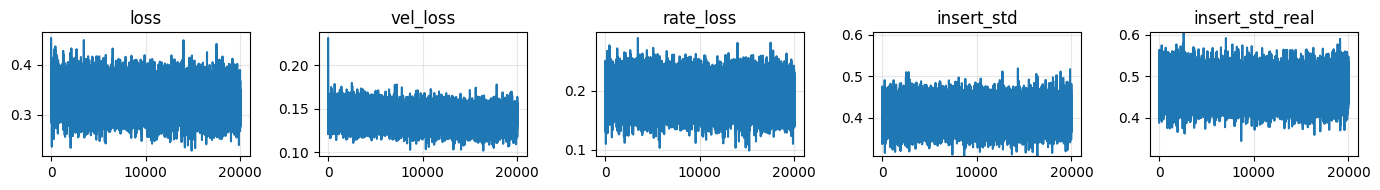

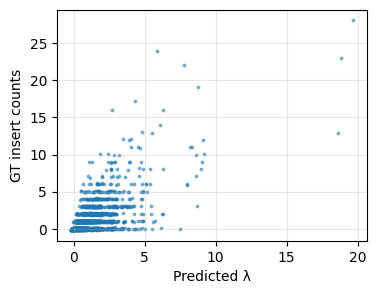

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20001/20001 [10:42<00:00, 31.12it/s]

[20000] loss=0.2804  vel=0.1402  rate=0.1403  std_ins=0.3986
timings:  data=0.0017s  forward=0.0023s  backward=0.0064s  loss=0.0004s  transform=0.0014s


In [ ]:
for iteration in tqdm.tqdm(range(num_iter)):
    t_data_start = time.time()

    # ======== 1. SAMPLE TARGET + NOISE ========
    Y1, M1, vid_lengths = gen_z1(batch_size=batch_size, padding_idx=padding_index, device=device)
    time_stats["data"].append(time.time() - t_data_start)

    t_transform_start = time.time()

    Y0 = torch.randn_like(Y1)
    M0 = torch.zeros_like(M1)

    # Sample seed frames
    start_frames = sample_start_frames(M1, k=num_start_frames, skip_first=1)
    M0[start_frames] = 1
    M0[torch.arange(M0.shape[0], device=device), vid_lengths - 1] = 1  # last frame always present

    # No context masking for t2v and unconditinal generation
    ctx_mask = torch.zeros_like(M1, dtype=torch.bool)

    # ======== 2. TAU SAMPLING (updated scheme) ========
    tau, tau_0 = sample_tau_tau_max(
        start_frames=start_frames,
        M1=M1,
        ctx_mask=ctx_mask,
        vid_lengths=vid_lengths,
        device=device,
        global_dist="uniform",
    )

    # Masking condition: frames with tau >= 0 get interpolated
    masking_cond = tau >= 0
    t_raw = torch.clip(tau, 0.0, 1.0)  # insertion clock (raw)
    t_den = scale_snr(t_raw, sigma_scale=sigma_scale)  # denoising clock (warped)
    Y_t = (1 - t_den[:, :, None, None, None]) * Y0 + t_den[:, :, None, None, None] * Y1

    M_t = torch.where(masking_cond, M1, M0)
    M_t[:, 0] = 1  # first frame always visible

    Y_t_masked = torch.where(
        M_t[:, :, None, None, None],
        Y_t,
        torch.full_like(Y0, padding_index),
    )

    # ======== 3. COMPUTE INSERT COUNTS ========
    insert_site_mask = (M_t == 0) & (M1 == 1)
    valid_frame_mask = torch.arange(M_t.shape[1], device=device)[None, :] < vid_lengths[:, None]
    insert_site_mask = insert_site_mask & valid_frame_mask
    flow_site_mask = (M_t == 1) & valid_frame_mask

    insert_counts = compute_insert_counts(insert_site_mask, flow_site_mask)

    # ======== 4. LEFT-ALIGN (strip padding) ========
    X_t, left_aligned_indices = left_align_by_mask(Y_t, M_t)
    X_t_m, _ = left_align_by_mask(Y_t_masked, M_t)

    t_left_aligned_den, _ = left_align_by_mask(t_den, M_t)
    t_left_aligned_raw, _ = left_align_by_mask(t_raw, M_t)
    tau_left_aligned, _ = left_align_by_mask(tau, M_t)
    M_left_aligned, _ = left_align_by_mask(M_t, M_t)

    B, L = Y1.shape[:2]
    aug_indices = left_aligned_indices.view(B, L, 1, 1, 1).expand(-1, -1, H, W, C)

    aligned_flow_site_mask = torch.gather(flow_site_mask, dim=1, index=left_aligned_indices)
    aligned_insert_counts = torch.gather(insert_counts, dim=1, index=left_aligned_indices)

    time_stats["transform"].append(time.time() - t_transform_start)

    # ======== 5. MODEL FORWARD ========
    t_forward_start = time.time()
    velocity_pred, lambda_ins_pred = compute_model(X_t_m, t_left_aligned_den, M_left_aligned, model)
    time_stats["forward"].append(time.time() - t_forward_start)

    # ======== 6. LOSSES ========
    t_loss_start = time.time()

    target_velocity = torch.gather(Y1 - Y0, dim=1, index=aug_indices)

    # Valid flow mask: aligned flow sites with tau in [0, 1)
    valid_flow_mask = aligned_flow_site_mask & (tau_left_aligned >= 0.0) & (tau_left_aligned < 1.0)

    # Velocity loss (masked MSE)
    mask5 = valid_flow_mask[:, :, None, None, None].float()
    diff2 = (velocity_pred - target_velocity).pow(2)
    denom = (mask5.sum() * C * H * W).clamp_min(1e-8)
    vel_loss = (diff2 * mask5).sum() / denom

    # Rate loss (Poisson NLL)
    rate_loss = poisson_loss(lambda_ins_pred, aligned_insert_counts, valid_flow_mask, tau_left_aligned)

    loss = vel_loss + rate_loss

    time_stats["loss"].append(time.time() - t_loss_start)

    # ======== 7. BACKWARD + STEP ========
    t_backward_start = time.time()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    time_stats["backward"].append(time.time() - t_backward_start)

    # ======== 8. LOGGING ========
    loss_dict["loss"].append(loss.detach().cpu().item())
    loss_dict["vel_loss"].append(vel_loss.detach().cpu().item())
    loss_dict["rate_loss"].append(rate_loss.detach().cpu().item())
    loss_dict["insert_std"].append(
        (valid_flow_mask * torch.poisson(lambda_ins_pred)).std(dim=1).mean().detach().cpu().item()
    )
    loss_dict["insert_std_real"].append(
        (valid_flow_mask * aligned_insert_counts).float().std(dim=1).mean().detach().cpu().item()
    )

    if iteration % 100 == 0:
        clear_output(wait=True)
        fig, ax = plt.subplots(1, len(loss_dict), figsize=(14, 2))
        insert_std_vals = loss_dict["insert_std"] + loss_dict["insert_std_real"]
        for i, (k, v) in enumerate(loss_dict.items()):
            ax[i].plot(v)
            ax[i].set_title(k)
            ax[i].grid(alpha=0.3)
            if "insert_std" in k and insert_std_vals:
                ax[i].set_ylim(min(insert_std_vals), max(insert_std_vals))
        plt.tight_layout()
        plt.show()

        # Scatter: predicted vs actual insert counts
        plt.figure(figsize=(4, 3))
        noise = 0.05 * torch.randn_like(lambda_ins_pred)
        plt.scatter(
            (lambda_ins_pred * valid_flow_mask + noise).flatten().tolist(),
            (aligned_insert_counts * valid_flow_mask + noise).flatten().tolist(),
            alpha=0.5,
            s=3,
        )
        plt.grid(alpha=0.3)
        plt.xlabel("Predicted λ")
        plt.ylabel("GT insert counts")
        plt.show()

    if iteration % 50 == 0:
        print(
            f"[{iteration}] loss={loss.item():.4f}  vel={vel_loss.item():.4f}  "
            f"rate={rate_loss.item():.4f}  std_ins={lambda_ins_pred.std(dim=1).mean():.4f}"
        )
        time_str = "timings:"
        for k1, v1 in time_stats.items():
            time_str += f"  {k1}={np.mean(v1[-100:]):.4f}s"
        print(time_str)

In [ ]:
# Optional: save checkpoint
# torch.save(model.state_dict(), "./checkpoints/model.pt")

## 6. Sampling — `sample_flowception_t2v`

At sampling time, we repeatedly:

1. **Denoise / flow-step** the currently-present frames (on active sites)
2. **Insert** new frames according to a learned per-frame insertion intensity

This implementation includes a few important correctness details:

- **Bernoulli thinning** (stable) instead of raw Poisson draws:
  $$p = 1 - e^{-\Lambda}$$
  where $\Lambda$ is the integrated intensity for a candidate insertion.

- **SNR-warped** flow steps (same time convention as training)

- **Per-sample** insertion placement (avoids batch-global indexing mistakes)

- **Mask-based** $\lambda$ zeroing (never rely on pixel-value comparisons to detect padding)


In [53]:
@torch.inference_mode()
def sample_flowception_t2v(
    first_frames,
    model,
    num_steps,
    batch_size=1,
    input_length=32,
    device="cuda",
    padding_index=0,
    start_frames=10,
    snr_shift=1.0,
):
    """
    FlowCeption sampling for text-to-video (no conditioning context).
    Uses Bernoulli thinning for insertions and SNR-warped flow steps.
    """
    H, W, C = first_frames.shape[-3:]
    B = batch_size
    num_frames = input_length

    # --- Initialize sequence ---
    Y_t = torch.full((B, num_frames, H, W, C), padding_index, device=device, dtype=torch.float32)
    M_t = torch.zeros((B, num_frames), device=device, dtype=torch.bool)
    dt_u = torch.full((B, num_frames), 1.0 / num_steps, device=device)
    current_u = torch.zeros((B, num_frames), device=device)

    # Place start frames
    K = 0
    rand_len = max(0, min(start_frames, num_frames - K))
    if rand_len > 0:
        Y_t[:, K : K + rand_len] = torch.randn_like(Y_t[:, K : K + rand_len])
        M_t[:, K : K + rand_len] = True

    insert_time_map = torch.full((B, num_frames), -1.0, dtype=torch.float32, device=device)
    insert_time_map[M_t] = 0.0

    Y_T_list, M_t_list = [], []
    total_inserts = torch.zeros(B, device=device)

    for step in tqdm.tqdm(range(2 * num_steps), desc="Sampling"):
        # SNR-warped times
        t = scale_snr(current_u, sigma_scale=snr_shift)
        u_next = (current_u + dt_u).clamp(0.0, 1.0)
        t_next = scale_snr(u_next, sigma_scale=snr_shift)
        h_flow = torch.where(current_u < 1.0, t_next - t, torch.zeros_like(t))

        # --- Forward ---
        velocity_pred, lambda_ins_pred = compute_model(Y_t, t, M_t, model)

        # Mask lambda using M_t (not pixel values)
        lambda_ins_pred = lambda_ins_pred.masked_fill(~M_t, 0.0)

        # --- Flow update ---
        Y_t = Y_t + h_flow[:, :, None, None, None] * velocity_pred

        # --- Insertion hazard ---
        ins_u = torch.max(current_u, dim=1, keepdim=True).values
        kappa_u = ins_u.clamp(0.0, 1.0)
        d_kappa = torch.full_like(current_u, 1.0)
        d_kappa[(ins_u < 0)[:, 0]] = 0.0

        h_ins = torch.where(
            (ins_u + dt_u[:, :1] < 1.0),
            torch.ones_like(current_u) / num_steps,
            torch.zeros_like(current_u),
        )

        ratio = torch.where(current_u < 0.0, torch.zeros_like(current_u), d_kappa / (1.0 - kappa_u))
        Lambda = (lambda_ins_pred * h_ins * ratio).clamp_min(0.0)
        Lambda[(ins_u < 0.0)[:, 0], :] = 0.0

        # Bernoulli thinning: p = 1 - exp(-Lambda)
        prob = (1.0 - torch.exp(-Lambda)).clamp(0.0, 1.0)
        insert_counts = (torch.rand_like(prob) < prob).to(torch.int32)

        # Advance clocks
        current_u = torch.where(current_u < 1.0, u_next, current_u)

        num_inserted = int(insert_counts.sum().item())

        # --- Perform insertions ---
        if num_inserted > 0:
            num_insertions = insert_counts.sum(dim=1).to(torch.int64)
            Imax = int(num_insertions.max().item())
            if Imax > 0:
                Lnew = num_frames + Imax
                inserting_frames = torch.randn((B, Imax, H, W, C), device=device, dtype=Y_t.dtype)

                # Compute where real frames land after inserting
                real_frames_pos = torch.arange(num_frames, device=device)[None, :].repeat(B, 1)
                real_frames_pos[:, 1:] += insert_counts.cumsum(dim=1)[:, :-1].to(torch.int64)

                # Allocate expanded buffers
                expanded_frames = torch.full(
                    (B, Lnew, H, W, C), padding_index, device=device, dtype=Y_t.dtype
                )
                expanded_mask = torch.zeros((B, Lnew), device=device, dtype=torch.bool)
                expanded_times = torch.zeros((B, Lnew), device=device, dtype=current_u.dtype)
                expanded_ins_times = torch.full((B, Lnew), -1.0, device=device, dtype=insert_time_map.dtype)

                bidx = torch.arange(B, device=device)[:, None]
                expanded_frames[bidx, real_frames_pos] = Y_t
                expanded_mask[bidx, real_frames_pos] = M_t
                expanded_times[bidx, real_frames_pos] = current_u
                expanded_ins_times[bidx, real_frames_pos] = insert_time_map

                # Per-sample insertion positions
                insert_mask = torch.ones((B, Lnew), device=device, dtype=torch.bool)
                insert_mask.scatter_(1, real_frames_pos, False)
                insert_rank = insert_mask.cumsum(dim=1) - 1
                keep_insert = insert_mask & (insert_rank < num_insertions[:, None])

                bi, pos = torch.where(keep_insert)
                if bi.numel() > 0:
                    r = insert_rank[bi, pos].to(torch.int64)
                    expanded_frames[bi, pos] = inserting_frames[bi, r]
                    expanded_mask[bi, pos] = True
                    expanded_ins_times[bi, pos] = float(step)

                # Clip back to fixed length
                Y_t = expanded_frames[:, :num_frames]
                M_t = expanded_mask[:, :num_frames]
                current_u = expanded_times[:, :num_frames]
                insert_time_map = expanded_ins_times[:, :num_frames]

        # Re-apply padding mask
        Y_t = torch.where(M_t[:, :, None, None, None], Y_t, torch.full_like(Y_t, padding_index))

    Y_T_list.append(Y_t.clone())
    M_t_list.append(M_t.clone())
    return Y_t, M_t, Y_T_list, M_t_list, insert_time_map

## 7. Generate & Visualize

In [54]:
bs = 8
with torch.no_grad():
    ground_truths = gen_z1(bs, padding_index, device=device)[0]
    first_frames = ground_truths[:, :1]

    Y_out, M_out, Y_list, M_list, insert_time_map = sample_flowception_t2v(
        first_frames,
        model,
        num_steps=50,
        batch_size=bs,
        input_length=num_frames,
        device=device,
        padding_index=padding_index,
        start_frames=num_start_frames,
        snr_shift=sigma_scale,
    )

Sampling:  33%|████████████████████████████████████████████████████████████████▋                                                                                                                                   | 33/100 [00:00<00:00, 321.84it/s]

Sampling: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 354.84it/s]


Video 0: 18 frames out of 30


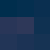

Video 1: 20 frames out of 30


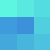

Video 2: 30 frames out of 30


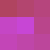

Video 3: 25 frames out of 30


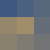

Video 4: 15 frames out of 30


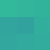

Video 5: 25 frames out of 30


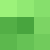

Video 6: 15 frames out of 30


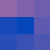

Video 7: 25 frames out of 30


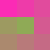

In [55]:
# --- Display generated videos as GIFs ---
savedir = "./videos_editflow/generated"
os.makedirs(savedir, exist_ok=True)

Y_out_norm = Y_out * 0.25 + 0.5  # undo normalization

for ii, (all_images, non_paddings) in enumerate(zip(Y_out_norm.float().cpu()[:8], M_out.float().cpu()[:8])):
    all_images = F.interpolate(all_images, size=(50, 50), mode="nearest")  # [T, C, 50, 50]
    img_cat = all_images[non_paddings.bool(), :, :, :]
    valid_count = non_paddings.sum().item()
    print(f"Video {ii}: {int(valid_count)} frames out of {num_frames}")

    img_cat = img_cat.detach().cpu().numpy()

    # Display GIF
    display(frames_to_gif(img_cat, fps=10, save_path=f"{savedir}/gen_{ii}.gif"))

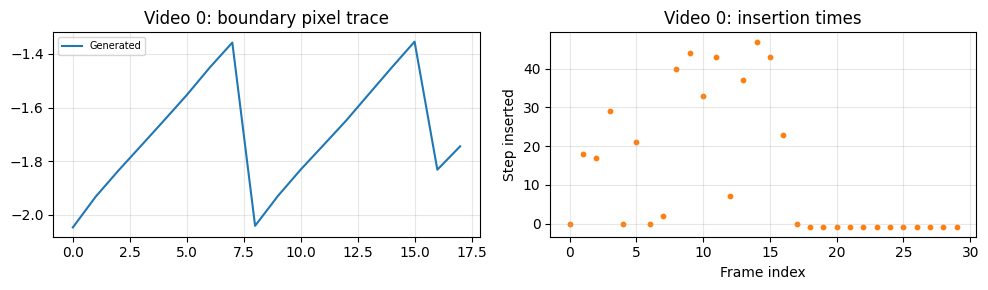

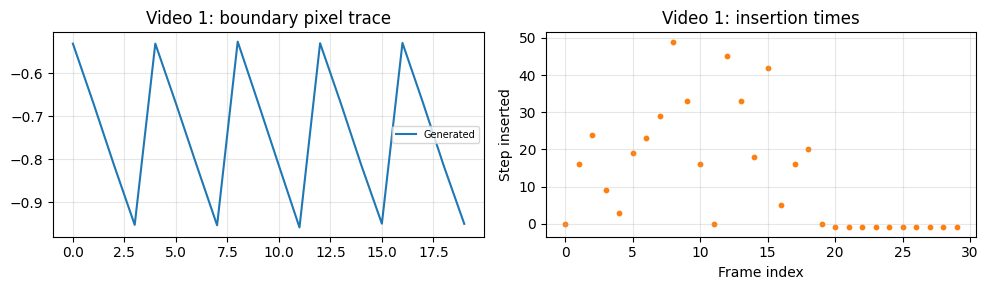

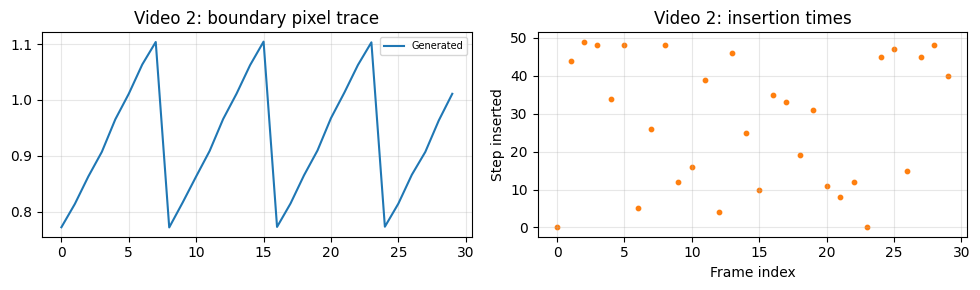

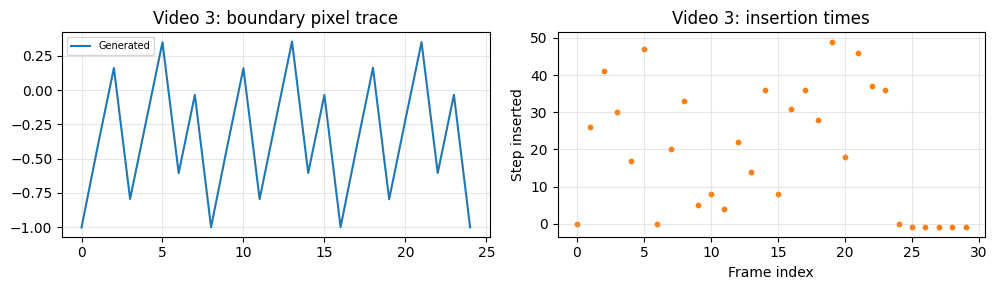

In [56]:
# --- Diagnostic: pixel traces + insertion times ---
for k in range(min(4, bs)):
    fig, ax = plt.subplots(1, 2, figsize=(10, 3))

    # Pixel trace at center (1,1)
    length = M_out[k].sum().tolist()

    ax[0].plot(torch.arange(length), Y_out[k, :length, 0, 0, 0].detach().cpu(), label="Generated")
    ax[0].set_title(f"Video {k}: boundary pixel trace")
    ax[0].legend(fontsize=7)
    ax[0].grid(alpha=0.3)

    # Insertion time map
    ax[1].scatter(
        np.arange(len(insert_time_map[0])),
        insert_time_map[k].detach().cpu(),
        s=10,
        c="tab:orange",
    )
    ax[1].set_title(f"Video {k}: insertion times")
    ax[1].set_xlabel("Frame index")
    ax[1].set_ylabel("Step inserted")
    ax[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

# Video Lengths Comparison

Below we compare **ground-truth** toy video lengths against **sampled** lengths from the trained model to sanity-check
that the insertion mechanism is producing plausible sequence lengths (even in this tiny setting).


Sampling: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:13<00:00,  7.52it/s]

num farmes out of 31:  15.0


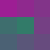

num farmes out of 31:  30.0


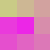

num farmes out of 31:  18.0


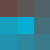

num farmes out of 31:  15.0


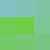

num farmes out of 31:  30.0


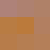

num farmes out of 31:  29.0


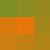

num farmes out of 31:  21.0


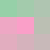

num farmes out of 31:  30.0


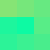

In [ ]:
# model_state_dict = torch.load("model.pt")
# model.load_state_dict(model_state_dict)

bs = 512

Y1, M1, vid_lengths = gen_z1(batch_size=batch_size, padding_idx=padding_index, device=device)

with torch.no_grad():
    # first_frames = generate_linear_interpolation(bs, num_frames)[:, :1].to(device)
    ground_truths = gen_z1(bs, padding_index, device=device)[0]
    first_frames = ground_truths[:, :1]
    # Y_out, M_out, Y_list, M_list, i
    Y_out, M_out, Y_list, M_list, insert_time_map = sample_flowception_t2v(
        first_frames,
        model,
        num_steps=50,
        batch_size=bs,
        input_length=num_frames,
        device=device,
        padding_index=padding_index,
        start_frames=num_start_frames,
        snr_shift=sigma_scale,
    )

savedir = "./flowception_samples/tutorial_v0"
Y_out_norm = Y_out * 0.25 + 0.5

for ii, (all_images, non_paddings) in enumerate(zip(Y_out_norm.float().cpu()[:8], M_out.float().cpu()[:8])):
    if all_images.ndim == 4:
        all_images = F.interpolate(all_images, (50, 50), mode="nearest")
    else:
        all_images = F.interpolate(all_images[None], (50, 50), mode="nearest")[0]

    img_cat = all_images[non_paddings.bool(), :, :, :]
    print("num farmes out of 31: ", non_paddings.sum().item())

    img_cat = img_cat.detach().cpu().numpy()

    display(frames_to_gif(img_cat, fps=10, save_path=f"{savedir}/gen_{ii}.gif"))

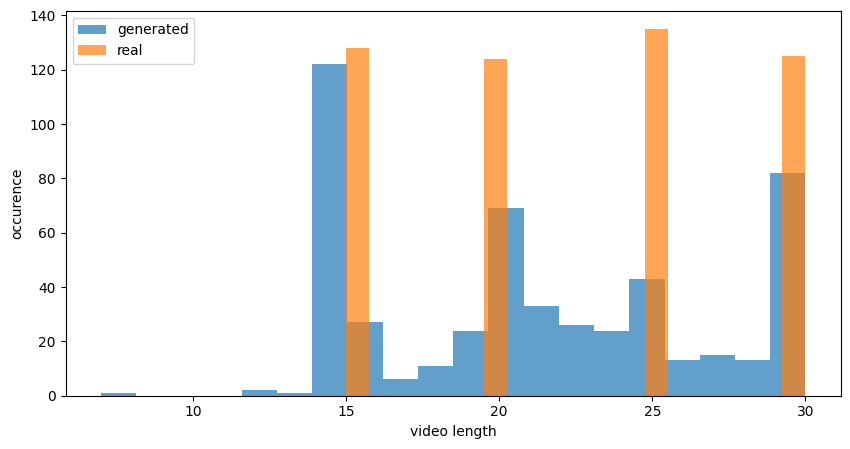

In [61]:
plt.figure(figsize=(10, 5))
plt.hist(M_out.sum(1).tolist(), bins=20, alpha=0.7, label="generated")
plt.hist(vid_lengths.tolist(), bins=20, alpha=0.7, label="real")
plt.xlabel("video length")
plt.ylabel("occurence")
plt.legend()